In [1]:
!pip install rasterio scikit-image opencv-python scipy

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# List all files in your Drive to find the correct path
print("Files in your Drive:")
for root, dirs, files in os.walk('/content/drive/My Drive'):
    for file in files:
        if file.endswith(('.tif', '.tiff')):
            full_path = os.path.join(root, file)
            print(full_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in your Drive:
/content/drive/My Drive/Classroom/SIG 2022 Jumat 11 - 13/12019012_Valina Rizky P_AreaKerja.tif
/content/drive/My Drive/GEOTHERMAL/DEMNAS_0619-32_v1.0.tif
/content/drive/My Drive/GEOTHERMAL/DEMNAS_0619-31_v1.0.tif
/content/drive/My Drive/es2/Flyyy.tif
/content/drive/My Drive/es2/riverrr.tif
/content/drive/My Drive/es2/FLYYYYYY.tif
/content/drive/My Drive/es2/contoh.tif
/content/drive/My Drive/es2/Papua.tif
/content/drive/My Drive/es2/mm.0.tif
/content/drive/My Drive/es2/papua_skel.tif
/content/drive/My Drive/es2/papua_link_directions.tif


Map shape: (1025, 4586)
Unique values: [0. 1.]
Water pixels: 681392


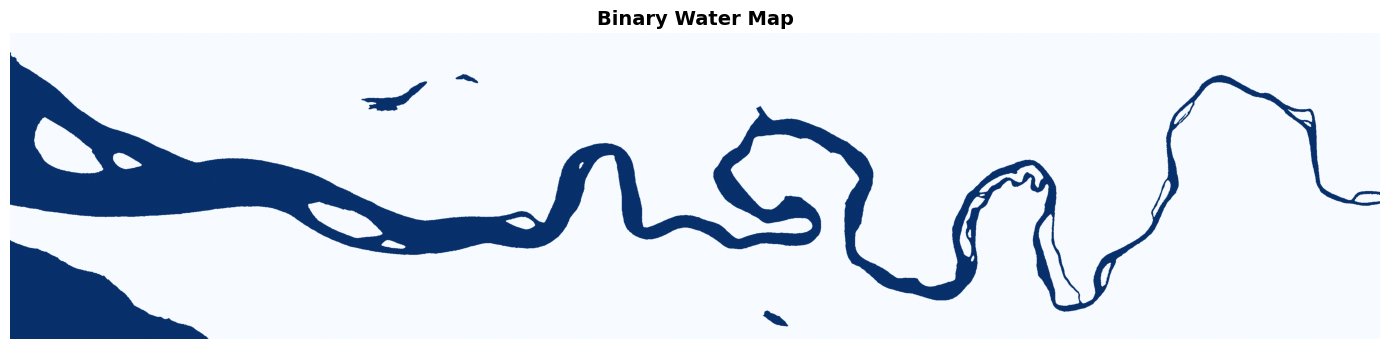

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import morphology
import cv2

# Load binary TIF file
def load_binary_map(filepath):
    """Load binary TIF file (water=1, non-water=0)"""
    with rasterio.open(filepath) as src:
        data = src.read(1)
        geotransform = src.transform
    return data, geotransform

# Load your data
binary_map, geotransform = load_binary_map('/content/drive/My Drive/es2/mm.0.tif')

print(f"Map shape: {binary_map.shape}")
print(f"Unique values: {np.unique(binary_map)}")
print(f"Water pixels: {np.sum(binary_map > 0)}")

# Visualize
fig, axes = plt.subplots(1, 1, figsize=(14, 10))
axes.imshow(binary_map, cmap='Blues')
axes.set_title('Binary Water Map', fontweight='bold', fontsize=14)
axes.axis('off')
plt.tight_layout()
plt.show()


STEP 1: EXTRACTING SKELETON
✓ Skeleton extracted!
Skeleton pixels: 12714


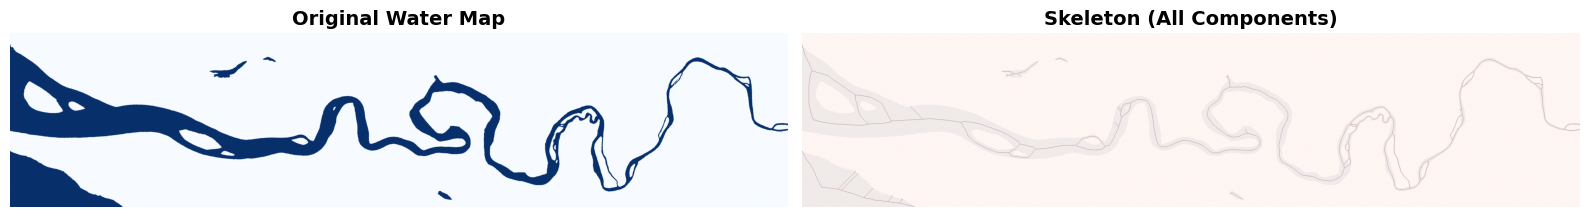

In [4]:
print("\n" + "="*70)
print("STEP 1: EXTRACTING SKELETON")
print("="*70)

def extract_skeleton(binary_map):
    """Extract skeleton/centerline using morphological thinning."""
    skeleton = morphology.skeletonize(binary_map)
    return skeleton

skeleton = extract_skeleton(binary_map)
print(f"✓ Skeleton extracted!")
print(f"Skeleton pixels: {np.sum(skeleton > 0)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(binary_map, cmap='Blues')
axes[0].set_title('Original Water Map', fontweight='bold', fontsize=14)
axes[0].axis('off')

axes[1].imshow(binary_map, cmap='Blues', alpha=0.3)
axes[1].imshow(skeleton, cmap='Reds', alpha=0.8)
axes[1].set_title('Skeleton (All Components)', fontweight='bold', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


STEP 1: IDENTIFYING NODES (JUNCTIONS AND ENDPOINTS) AND LINKS
✓ Identified 191 junction points (nodes).
✓ Identified 39 endpoints (nodes).
✓ Identified 114 individual links.

STEP 2: VISUALIZING NODES AND LABELED LINKS


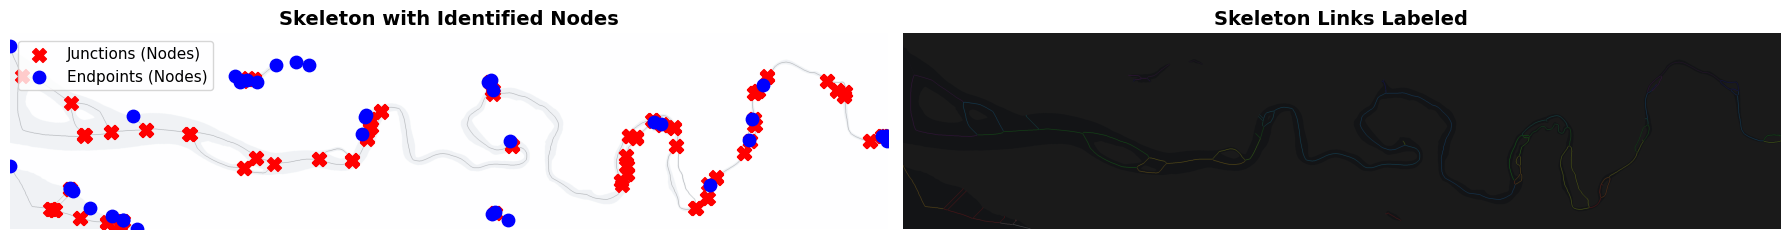


STEP 3: EXTRACTING LINK PROPERTIES (OPTIONAL)
Total 114 links identified.
Link properties (first 5 links):

   link_id  length_pixels
0        1            156
1        2             70
2        3            320
3        4            118
4        5            256


In [5]:
import numpy as np
from skimage import morphology
from scipy import ndimage
import matplotlib.pyplot as plt
import pandas as pd # pandas is already imported in previous cells

print("\n" + "="*70)
print("STEP 1: IDENTIFYING NODES (JUNCTIONS AND ENDPOINTS) AND LINKS")
print("="*70)

def find_nodes_and_links(skeleton_image):
    """
    Identifies junction points (nodes) and endpoints in a skeletonized image,
    and then segments the skeleton into individual links.

    Args:
        skeleton_image (np.ndarray): A binary skeleton image (True/False or 1/0).

    Returns:
        tuple: A tuple containing:
            - junctions (np.ndarray): Coordinates (y, x) of junction points.
            - endpoints (np.ndarray): Coordinates (y, x) of endpoints.
            - labeled_links (np.ndarray): An integer array where each connected
              link segment is assigned a unique positive integer label.
              Background is 0.
            - num_links (int): The total number of identified links.
    """
    # Convert skeleton to integer for processing
    skel_int = skeleton_image.astype(int)

    # Define a 3x3 kernel for neighbor counting (8-connectivity)
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]], dtype=np.uint8)

    # Count neighbors for each skeleton pixel
    # This gives the number of 8-connected neighbors that are also skeleton pixels
    neighbor_count = ndimage.convolve(skel_int, kernel, mode='constant', cval=0) * skel_int

    # Identify endpoints (1 neighbor)
    endpoints = np.argwhere(neighbor_count == 1)

    # Identify junction points (more than 2 neighbors)
    # The skeletonize function can sometimes leave small loops that appear as junctions
    # but are not true branch points. A more sophisticated graph approach would handle this.
    # For this approach, we consider any pixel with > 2 neighbors as a junction.
    junctions = np.argwhere(neighbor_count > 2)

    # Create a temporary skeleton where junctions are removed to isolate links
    temp_skeleton = np.copy(skel_int)

    # Remove junction pixels from the temporary skeleton
    for y, x in junctions:
        temp_skeleton[y, x] = 0

    # Label the connected components in the temporary skeleton
    # Each component is a "link" or a segment between nodes
    labeled_links, num_links = ndimage.label(temp_skeleton, structure=np.ones((3,3)))

    return junctions, endpoints, labeled_links, num_links

# Call the function to find nodes and links using the full 'skeleton' from previous steps
junction_points, end_points, labeled_links, num_links = find_nodes_and_links(skeleton)

print(f"✓ Identified {len(junction_points)} junction points (nodes).")
print(f"✓ Identified {len(end_points)} endpoints (nodes).")
print(f"✓ Identified {num_links} individual links.")

print("\n" + "="*70)
print("STEP 2: VISUALIZING NODES AND LABELED LINKS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Plot the original skeleton with identified nodes
axes[0].imshow(binary_map, cmap='Blues', alpha=0.3) # Show original map faintly
axes[0].imshow(skeleton, cmap='Greys', alpha=0.8)
if len(junction_points) > 0:
    axes[0].scatter(junction_points[:, 1], junction_points[:, 0], c='red', s=100, marker='X', label='Junctions (Nodes)', zorder=5)
if len(end_points) > 0:
    axes[0].scatter(end_points[:, 1], end_points[:, 0], c='blue', s=80, marker='o', label='Endpoints (Nodes)', zorder=5)
axes[0].set_title('Skeleton with Identified Nodes', fontweight='bold', fontsize=14)
axes[0].axis('off')
axes[0].legend(fontsize=11)

# Plot the labeled links
# Use a colormap for distinct labels. Add 1 to num_links for background (label 0).
cmap = plt.get_cmap('nipy_spectral', num_links + 1)
axes[1].imshow(binary_map, cmap='Blues', alpha=0.3) # Show original map faintly
axes[1].imshow(labeled_links, cmap=cmap, alpha=0.9)
axes[1].set_title('Skeleton Links Labeled', fontweight='bold', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("STEP 3: EXTRACTING LINK PROPERTIES (OPTIONAL)")
print("="*70)

# Example: Get length of each link
link_lengths = []
for i in range(1, num_links + 1):
    link_pixels = np.argwhere(labeled_links == i)
    if len(link_pixels) > 0:
        length = len(link_pixels) # Simple pixel count as length
        link_lengths.append({'link_id': i, 'length_pixels': length})

df_links = pd.DataFrame(link_lengths)
if not df_links.empty:
    print(f"Total {len(df_links)} links identified.")
    print("Link properties (first 5 links):\n")
    print(df_links.head().to_string())
else:
    print("No links found.")

# You can further analyze each link, e.g., to get its coordinates, direction, etc.
# For example, to get coordinates of link 1:
# if num_links >= 1:
#     link1_coords = np.argwhere(labeled_links == 1)
#     print(f"\nCoordinates for Link 1 (first 5 pixels):\n")
#     print(link1_coords[:5])



STEP 7: VISUALIZING A SPECIFIC LINK BY ID
Enter the Link ID you want to visualize.
Available link IDs are from 1 to 114 (total 114 original links).
Enter Link ID: 35


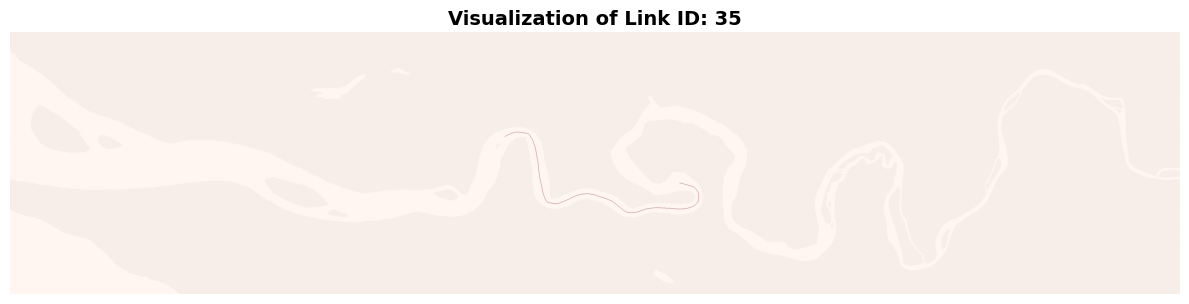

In [6]:
print("\n" + "="*70)
print("STEP 7: VISUALIZING A SPECIFIC LINK BY ID")
print("="*70)

def visualize_specific_link(link_id, labeled_links, binary_map):
    """
    Visualizes a single specified link from the labeled_links array.

    Args:
        link_id (int): The ID of the link to visualize.
        labeled_links (np.ndarray): The array with all labeled links.
        binary_map (np.ndarray): The original binary map for context.
    """
    if link_id <= 0 or link_id > labeled_links.max():
        print(f"Error: Link ID {link_id} is out of bounds. Please choose an ID between 1 and {labeled_links.max()}.")
        return

    # Create a mask for the specific link
    specific_link_mask = (labeled_links == link_id)

    fig, ax = plt.subplots(figsize=(12, 12))

    # Display the binary map as background
    ax.imshow(binary_map, cmap='Greys_r', alpha=0.3)

    # Display the specific link
    # Use a single color (e.g., 'red') for the selected link
    ax.imshow(specific_link_mask, cmap='Reds', alpha=0.9)

    ax.set_title(f'Visualization of Link ID: {link_id}', fontweight='bold', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- Example Usage --- #
print("Enter the Link ID you want to visualize.")
print(f"Available link IDs are from 1 to {labeled_links.max()} (total {num_links} original links).")

try:
    selected_link_id = int(input("Enter Link ID: "))
    visualize_specific_link(selected_link_id, labeled_links, binary_map)
except ValueError:
    print("Invalid input. Please enter an integer.")



STEP: VISUALIZING ALL LINKS WITH THEIR IDs


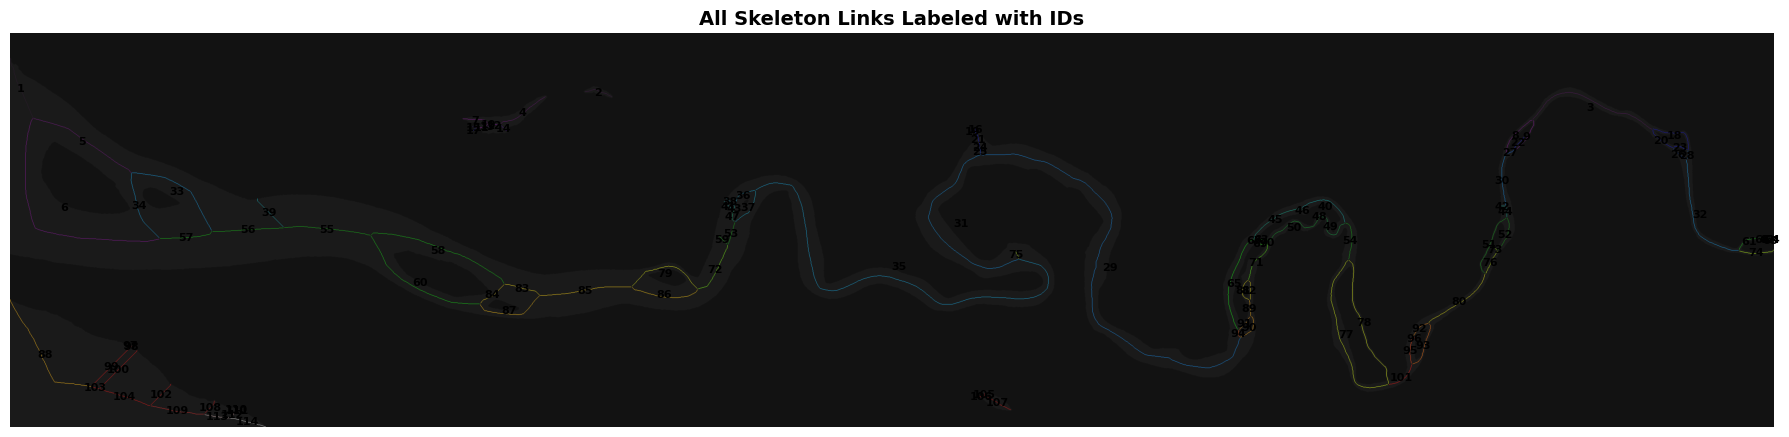

In [7]:
print("\n" + "="*70)
print("STEP: VISUALIZING ALL LINKS WITH THEIR IDs")
print("="*70)

def visualize_all_links_with_ids(labeled_links, binary_map, num_links):
    """
    Visualizes all individual links from the labeled_links array with their IDs.

    Args:
        labeled_links (np.ndarray): An integer array where each connected
          link segment is assigned a unique positive integer label.
        binary_map (np.ndarray): The original binary map for context.
        num_links (int): The total number of identified links.
    """
    fig, ax = plt.subplots(figsize=(18, 9))

    # Display the binary map as background with 'Greys_r' for bright mode
    ax.imshow(binary_map, cmap='Greys_r', alpha=0.3)

    # Use a colormap for distinct labels. Add 1 to num_links for background (label 0).
    cmap = plt.get_cmap('nipy_spectral', num_links + 1)
    ax.imshow(labeled_links, cmap=cmap, alpha=0.9)

    # Add text labels for each link ID
    for i in range(1, num_links + 1):
        # Get coordinates of the link's pixels
        link_pixels = np.argwhere(labeled_links == i)
        if len(link_pixels) > 0:
            # Calculate the center of the link for placing the label
            center_y, center_x = np.mean(link_pixels, axis=0).astype(int)

            # Adjust label position slightly if needed for better visibility
            ax.text(center_x, center_y, str(i), color='black', fontsize=8, ha='center', va='center', weight='bold')

    ax.set_title('All Skeleton Links Labeled with IDs', fontweight='bold', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Call the function to visualize all links with their IDs
visualize_all_links_with_ids(labeled_links, binary_map, num_links)


In [8]:
import numpy as np
import pandas as pd
from scipy import ndimage
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("STEP: MEASURING WIDTHS FOR EACH INDIVIDUAL LINK")
print("="*70)

def find_endpoints_for_mask(mask):
    """
    Find endpoints of a given binary mask (pixels with only 1 neighbor).
    Used for finding starting points for tracing individual links.
    """
    mask_int = mask.astype(int)
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]], dtype=np.uint8)
    neighbor_count = ndimage.convolve(mask_int, kernel, mode='constant', cval=0) * mask_int
    endpoints = np.argwhere(neighbor_count == 1)
    return endpoints

def trace_path_for_link(link_mask, start_y, start_x, max_length=100000):
    """
    Trace a continuous path from a starting point within a given link_mask.
    Returns the path as a list of (y, x) coordinates.
    """
    path = [(start_y, start_x)]
    visited = {(start_y, start_x)}
    current_y, current_x = start_y, start_x

    if not link_mask[start_y, start_x]:
        return []

    while len(path) < max_length:
        neighbors = []
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0:
                    continue
                ny, nx = current_y + dy, current_x + dx

                if (0 <= ny < link_mask.shape[0] and
                    0 <= nx < link_mask.shape[1] and
                    link_mask[ny, nx] == 1 and
                    (ny, nx) not in visited):
                    neighbors.append((ny, nx))

        if not neighbors:
            break

        if len(neighbors) == 1:
            current_y, current_x = neighbors[0]
        else:
            if len(path) > 1:
                prev_dy = path[-1][0] - path[-2][0]
                prev_dx = path[-1][1] - path[-2][1]

                best_neighbor = neighbors[0]
                best_score = float('-inf')

                for ny, nx in neighbors:
                    dy = ny - current_y
                    dx = nx - current_x
                    score = dy * prev_dy + dx * prev_dx
                    if score > best_score:
                        best_score = score
                        best_neighbor = (ny, nx)
                current_y, current_x = best_neighbor
            else:
                current_y, current_x = neighbors[0]

        path.append((current_y, current_x))
        visited.add((current_y, current_x))

    return path

def measure_width_perpendicular_to_path(binary_map, x_coords, y_coords, max_search_distance=200):
    """
    Measure the exact water width perpendicular to a given path (centerline points).
    Finds the actual water boundaries on both sides.

    Args:
        binary_map: Binary water map (water=1, non-water=0)
        x_coords: X coordinates of the path
        y_coords: Y coordinates of the path
        max_search_distance: Maximum distance to search for water boundary (pixels)

    Returns:
        DataFrame with width measurements for this path
    """
    width_measurements = []

    for i in range(len(x_coords)):
        current_x = x_coords[i]
        current_y = y_coords[i]

        if i == 0:
            dx = x_coords[i+1] - x_coords[i]
            dy = y_coords[i+1] - y_coords[i]
        elif i == len(x_coords) - 1:
            dx = x_coords[i] - x_coords[i-1]
            dy = y_coords[i] - y_coords[i-1]
        else:
            dx = x_coords[i+1] - x_coords[i-1]
            dy = y_coords[i+1] - y_coords[i-1]

        tangent_length = np.sqrt(dx**2 + dy**2)
        if tangent_length > 0:
            dx /= tangent_length
            dy /= tangent_length
        else:
            # If length is 0, path point is isolated, cannot determine perpendicular
            continue

        perp_dx = -dy
        perp_dy = dx

        width_left = 0
        width_right = 0

        # Search LEFT direction (negative perpendicular)
        for dist in range(1, max_search_distance + 1):
            check_x = int(current_x - perp_dx * dist)
            check_y = int(current_y - perp_dy * dist)

            if check_x < 0 or check_x >= binary_map.shape[1] or \
               check_y < 0 or check_y >= binary_map.shape[0]:
                break
            if binary_map[check_y, check_x] > 0:
                width_left = dist
            else:
                break

        # Search RIGHT direction (positive perpendicular)
        for dist in range(1, max_search_distance + 1):
            check_x = int(current_x + perp_dx * dist)
            check_y = int(current_y + perp_dy * dist)

            if check_x < 0 or check_x >= binary_map.shape[1] or \
               check_y < 0 or check_y >= binary_map.shape[0]:
                break
            if binary_map[check_y, check_x] > 0:
                width_right = dist
            else:
                break

        total_width = width_left + width_right

        if total_width > 0:
            width_measurements.append({
                'point_id_within_link': i,
                'centerline_x': current_x,
                'centerline_y': current_y,
                'width_left_pixels': width_left,
                'width_right_pixels': width_right,
                'total_width_pixels': total_width
            })

    return pd.DataFrame(width_measurements)


# --- Main logic to process each individual link --- #

all_link_width_data = []

print(f"Measuring width for a total of {num_links} individual links...")

for link_id in range(1, num_links + 1):
    # Create a binary mask for the current link
    link_mask = (labeled_links == link_id).astype(np.uint8)

    # Find a starting point for tracing this link
    link_endpoints = find_endpoints_for_mask(link_mask)

    start_point = None
    if len(link_endpoints) > 0:
        start_point = link_endpoints[0] # Use an actual endpoint if available
    else:
        # If no endpoints (e.g., a closed loop or a very short segment),
        # pick any pixel to start tracing
        any_pixel = np.argwhere(link_mask == 1)
        if len(any_pixel) > 0:
            start_point = any_pixel[0]

    if start_point is None:
        # Skip links with no pixels
        print(f"  Skipping empty or invalid link ID: {link_id}")
        continue

    start_y, start_x = start_point

    # Trace the path (centerline) for this individual link
    path_for_link = trace_path_for_link(link_mask, start_y, start_x)

    if len(path_for_link) < 2:
        # A link needs at least 2 points to determine a direction for perpendiculars
        print(f"  Skipping link ID {link_id}: Too short to measure width (length {len(path_for_link)} pixels)")
        continue

    x_coords_link = np.array([p[1] for p in path_for_link])
    y_coords_link = np.array([p[0] for p in path_for_link])

    # Measure width along this link's path
    link_df_widths = measure_width_perpendicular_to_path(
        binary_map, x_coords_link, y_coords_link, max_search_distance=200
    )

    if not link_df_widths.empty:
        # Add the current link_id to the DataFrame and append to results
        link_df_widths['original_link_id'] = link_id
        all_link_width_data.append(link_df_widths)


if all_link_width_data:
    final_df_link_widths = pd.concat(all_link_width_data, ignore_index=True)
    print(f"\n✓ Completed width measurement for all individual links. Total {len(final_df_link_widths)} width points measured across {len(final_df_link_widths['original_link_id'].unique())} links.")

    print("\n" + "="*80)
    print("TABULATION OF RIVER WIDTH MEASUREMENTS PER INDIVIDUAL LINK")
    print("="*80)
    print("First 15 measurements across all links (showing original_link_id and point_id_within_link):")
    print(final_df_link_widths.head(15).to_string())

    print(f"\nStatistics across all measured points (all links combined):")
    print(f"  Total width points measured: {len(final_df_link_widths)}")
    print(f"  Mean width: {final_df_link_widths['total_width_pixels'].mean():.2f} pixels")
    print(f"  Max width: {final_df_link_widths['total_width_pixels'].max():.2f} pixels")
    print(f"  Min width: {final_df_link_widths['total_width_pixels'].min():.2f} pixels")
    print(f"  Standard deviation: {final_df_link_widths['total_width_pixels'].std():.2f} pixels")

    # Group by original_link_id to get stats per link
    print("\nSummary: Mean, Min, Max width per link (first 10 links):")
    mean_width_per_link = final_df_link_widths.groupby('original_link_id')['total_width_pixels'].agg(['mean', 'min', 'max', 'count']).reset_index()
    mean_width_per_link.rename(columns={'count': 'num_measurements'}, inplace=True)
    print(mean_width_per_link.head(10).to_string())

else:
    print("No width measurements could be performed for any link. This might indicate that all links were too short or empty.")

# Optional: Export the detailed results to a CSV file
# final_df_link_widths.to_csv('all_links_width_measurements.csv', index=False)
# print("\nDetailed width measurements for all links exported to 'all_links_width_measurements.csv'")



STEP: MEASURING WIDTHS FOR EACH INDIVIDUAL LINK
Measuring width for a total of 114 individual links...
  Skipping link ID 24: Too short to measure width (length 1 pixels)
  Skipping link ID 67: Too short to measure width (length 1 pixels)
  Skipping link ID 98: Too short to measure width (length 1 pixels)

✓ Completed width measurement for all individual links. Total 12509 width points measured across 110 links.

TABULATION OF RIVER WIDTH MEASUREMENTS PER INDIVIDUAL LINK
First 15 measurements across all links (showing original_link_id and point_id_within_link):
    point_id_within_link  centerline_x  centerline_y  width_left_pixels  width_right_pixels  total_width_pixels  original_link_id
0                      1             0            68                  1                   0                   1                 1
1                      2             0            69                  2                   1                   3                 1
2                      3             1   


STEP 5: WIDTH PROFILE ANALYSIS FOR A SINGLE SELECTED LINK
Available link IDs for detailed analysis are from 1 to 114 (total 110 links with measurements).
Enter the Link ID you want to analyze in detail: 35
Plotting detailed width profile for Link ID: 35...


/tmp/ipykernel_25502/843489465.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


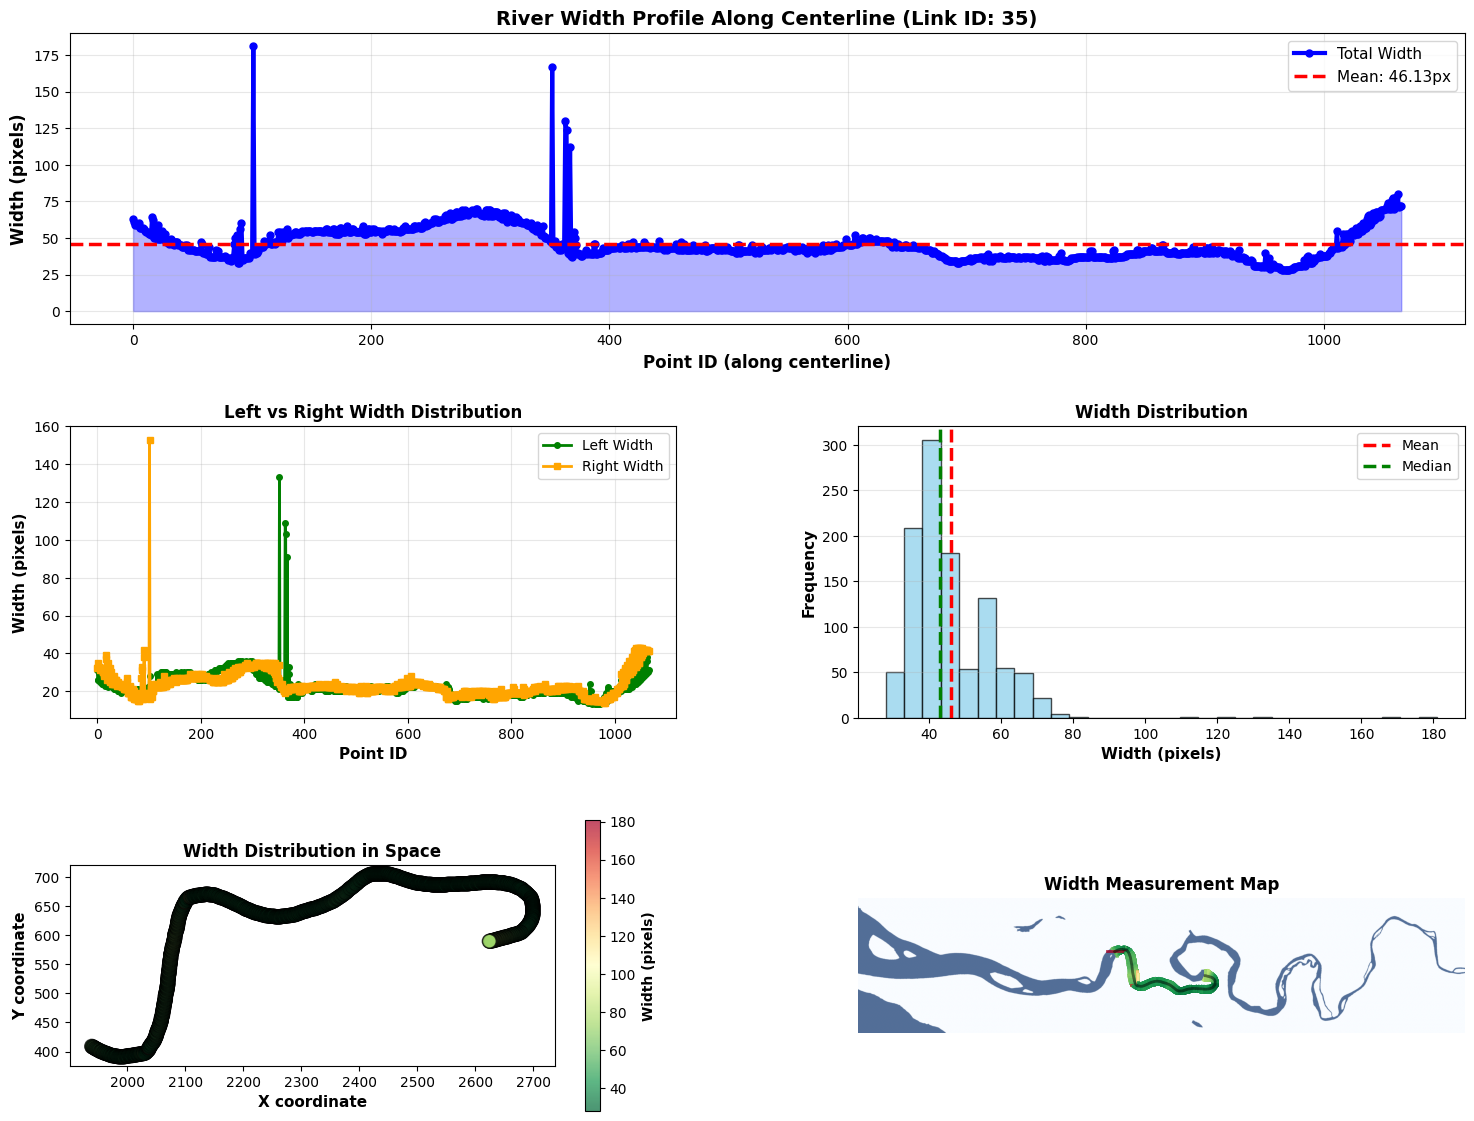

In [9]:
print("\n" + "="*70)
print("STEP 5: WIDTH PROFILE ANALYSIS FOR A SINGLE SELECTED LINK")
print("="*70)

def plot_detailed_width_profile(df_widths_single_link, binary_map, x_centerline, y_centerline, link_id):
    """Plot detailed width analysis for a single link."""

    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

    # Plot 1: Width profile with left/right breakdown
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df_widths_single_link['point_id_within_link'], df_widths_single_link['total_width_pixels'],
            'b-', linewidth=3, marker='o', markersize=5, label='Total Width')
    ax1.fill_between(df_widths_single_link['point_id_within_link'], df_widths_single_link['total_width_pixels'],
                    alpha=0.3, color='blue')
    ax1.axhline(y=df_widths_single_link['total_width_pixels'].mean(), color='r',
               linestyle='--', linewidth=2.5,
               label=f"Mean: {df_widths_single_link['total_width_pixels'].mean():.2f}px")
    ax1.set_xlabel('Point ID (along centerline)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Width (pixels)', fontsize=12, fontweight='bold')
    ax1.set_title(f'River Width Profile Along Centerline (Link ID: {link_id})', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11, loc='upper right')

    # Plot 2: Left vs Right width
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(df_widths_single_link['point_id_within_link'], df_widths_single_link['width_left_pixels'],
            'g-', linewidth=2, marker='o', markersize=4, label='Left Width')
    ax2.plot(df_widths_single_link['point_id_within_link'], df_widths_single_link['width_right_pixels'],
            'orange', linewidth=2, marker='s', markersize=4, label='Right Width')
    ax2.set_xlabel('Point ID', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Width (pixels)', fontsize=11, fontweight='bold')
    ax2.set_title('Left vs Right Width Distribution', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)

    # Plot 3: Width distribution histogram
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(df_widths_single_link['total_width_pixels'], bins=30, edgecolor='black',
            color='skyblue', alpha=0.7)
    ax3.axvline(x=df_widths_single_link['total_width_pixels'].mean(), color='r',
               linestyle='--', linewidth=2.5, label='Mean')
    ax3.axvline(x=df_widths_single_link['total_width_pixels'].median(), color='g',
               linestyle='--', linewidth=2.5, label='Median')
    ax3.set_xlabel('Width (pixels)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax3.set_title('Width Distribution', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')

    # Plot 4: Spatial width distribution
    ax4 = fig.add_subplot(gs[2, 0])
    scatter = ax4.scatter(df_widths_single_link['centerline_x'], df_widths_single_link['centerline_y'],
                         c=df_widths_single_link['total_width_pixels'], cmap='RdYlGn_r',
                         s=100, alpha=0.7, edgecolors='black', linewidth=1)
    ax4.set_xlabel('X coordinate', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Y coordinate', fontsize=11, fontweight='bold')
    ax4.set_title('Width Distribution in Space', fontsize=12, fontweight='bold')
    ax4.set_aspect('equal')
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Width (pixels)', fontsize=10, fontweight='bold')

    # Plot 5: Map with width lines
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.imshow(binary_map, cmap='Blues', alpha=0.7)

    # Plot width lines colored by width
    # Recalculate perp_dx, perp_dy for visualization if not directly available
    if 'perp_dx' not in df_widths_single_link.columns or 'perp_dy' not in df_widths_single_link.columns:
        temp_perp_dx = []
        temp_perp_dy = []
        # Ensure df_widths_single_link is mutable for adding new columns
        df_widths_single_link_copy = df_widths_single_link.copy()

        for i in range(len(df_widths_single_link_copy)):
            if i == 0:
                dx = df_widths_single_link_copy['centerline_x'].iloc[i+1] - df_widths_single_link_copy['centerline_x'].iloc[i]
                dy = df_widths_single_link_copy['centerline_y'].iloc[i+1] - df_widths_single_link_copy['centerline_y'].iloc[i]
            elif i == len(df_widths_single_link_copy) - 1:
                dx = df_widths_single_link_copy['centerline_x'].iloc[i] - df_widths_single_link_copy['centerline_x'].iloc[i-1]
                dy = df_widths_single_link_copy['centerline_y'].iloc[i] - df_widths_single_link_copy['centerline_y'].iloc[i-1]
            else:
                dx = df_widths_single_link_copy['centerline_x'].iloc[i+1] - df_widths_single_link_copy['centerline_x'].iloc[i-1]
                dy = df_widths_single_link_copy['centerline_y'].iloc[i+1] - df_widths_single_link_copy['centerline_y'].iloc[i-1]

            tangent_length = np.sqrt(dx**2 + dy**2)
            if tangent_length > 0:
                dx /= tangent_length
                dy /= tangent_length
            else:
                dx, dy = 0, 0 # Fallback

            temp_perp_dx.append(-dy)
            temp_perp_dy.append(dx)
        df_widths_single_link_copy['perp_dx'] = temp_perp_dx
        df_widths_single_link_copy['perp_dy'] = temp_perp_dy
        # Use the copy with perp_dx and perp_dy for plotting lines
        plot_df = df_widths_single_link_copy
    else:
        plot_df = df_widths_single_link

    colors = plt.cm.RdYlGn_r(
        (plot_df['total_width_pixels'] - plot_df['total_width_pixels'].min()) /
        (plot_df['total_width_pixels'].max() - plot_df['total_width_pixels'].min())
    )

    # Use iterrows on the DataFrame that was used to generate `colors`
    for idx, row in plot_df.iterrows():
        ax5.plot([row['centerline_x'] - row['perp_dx'] * row['width_left_pixels'],
                 row['centerline_x'] + row['perp_dx'] * row['width_right_pixels']],
                [row['centerline_y'] - row['perp_dy'] * row['width_left_pixels'],
                 row['centerline_y'] + row['perp_dy'] * row['width_right_pixels']],
                color=colors[plot_df.index.get_loc(idx)], linewidth=2, alpha=0.8) # Use get_loc for safe indexing

    ax5.plot(x_centerline, y_centerline, 'k-', linewidth=2, alpha=0.5)
    ax5.set_title('Width Measurement Map', fontsize=12, fontweight='bold')
    ax5.axis('off')

    plt.tight_layout()
    plt.show()


# --- User Interaction for selecting a link ---
print(f"Available link IDs for detailed analysis are from 1 to {num_links} (total {len(final_df_link_widths['original_link_id'].unique())} links with measurements).")

try:
    selected_link_id = int(input("Enter the Link ID you want to analyze in detail: "))

    # Filter data for the selected link
    df_selected_link_widths = final_df_link_widths[final_df_link_widths['original_link_id'] == selected_link_id].copy()
    df_selected_link_widths = df_selected_link_widths.reset_index(drop=True) # Reset index to ensure sequential indices for iteration

    if not df_selected_link_widths.empty:
        # Reconstruct the centerline for the selected link
        # Need to re-trace the path for the specific link from labeled_links as x_pruned_advanced, y_pruned_advanced is for the main centerline
        link_mask_selected = (labeled_links == selected_link_id).astype(np.uint8)
        link_endpoints_selected = find_endpoints_for_mask(link_mask_selected)

        start_point_selected = None
        if len(link_endpoints_selected) > 0:
            start_point_selected = link_endpoints_selected[0]
        else:
            any_pixel_selected = np.argwhere(link_mask_selected == 1)
            if len(any_pixel_selected) > 0:
                start_point_selected = any_pixel_selected[0]

        if start_point_selected is not None:
            path_for_selected_link = trace_path_for_link(link_mask_selected, start_point_selected[0], start_point_selected[1])
            x_centerline_selected = np.array([p[1] for p in path_for_selected_link])
            y_centerline_selected = np.array([p[0] for p in path_for_selected_link])

            # Plot detailed profile for the selected link
            print(f"Plotting detailed width profile for Link ID: {selected_link_id}...")
            plot_detailed_width_profile(df_selected_link_widths, binary_map, x_centerline_selected, y_centerline_selected, selected_link_id)
        else:
            print(f"Could not find a starting point to trace Link ID {selected_link_id}.")
    else:
        print(f"No width measurement data found for Link ID {selected_link_id}.")

except ValueError:
    print("Invalid input. Please enter an integer for Link ID.")
except NameError:
    print("Error: 'final_df_link_widths' or other required variables are not defined. Please run previous cells.")



Using a pixel size of 30.00 meters/pixel for conversion.

Converted DataFrame head (first 5 rows with new meter units):

   point_id_within_link    length_m  total_width_m
0                     0    0.000000         1890.0
1                     1   42.426407         1830.0
2                     2   72.426407         1770.0
3                     3  114.852814         1770.0
4                     4  144.852814         1770.0

STEP 5: WIDTH PROFILE ANALYSIS FOR A SINGLE SELECTED LINK (IN METERS)
Plotting detailed width profile for Link ID: 35 (in meters)...


/tmp/ipykernel_25502/3312094719.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


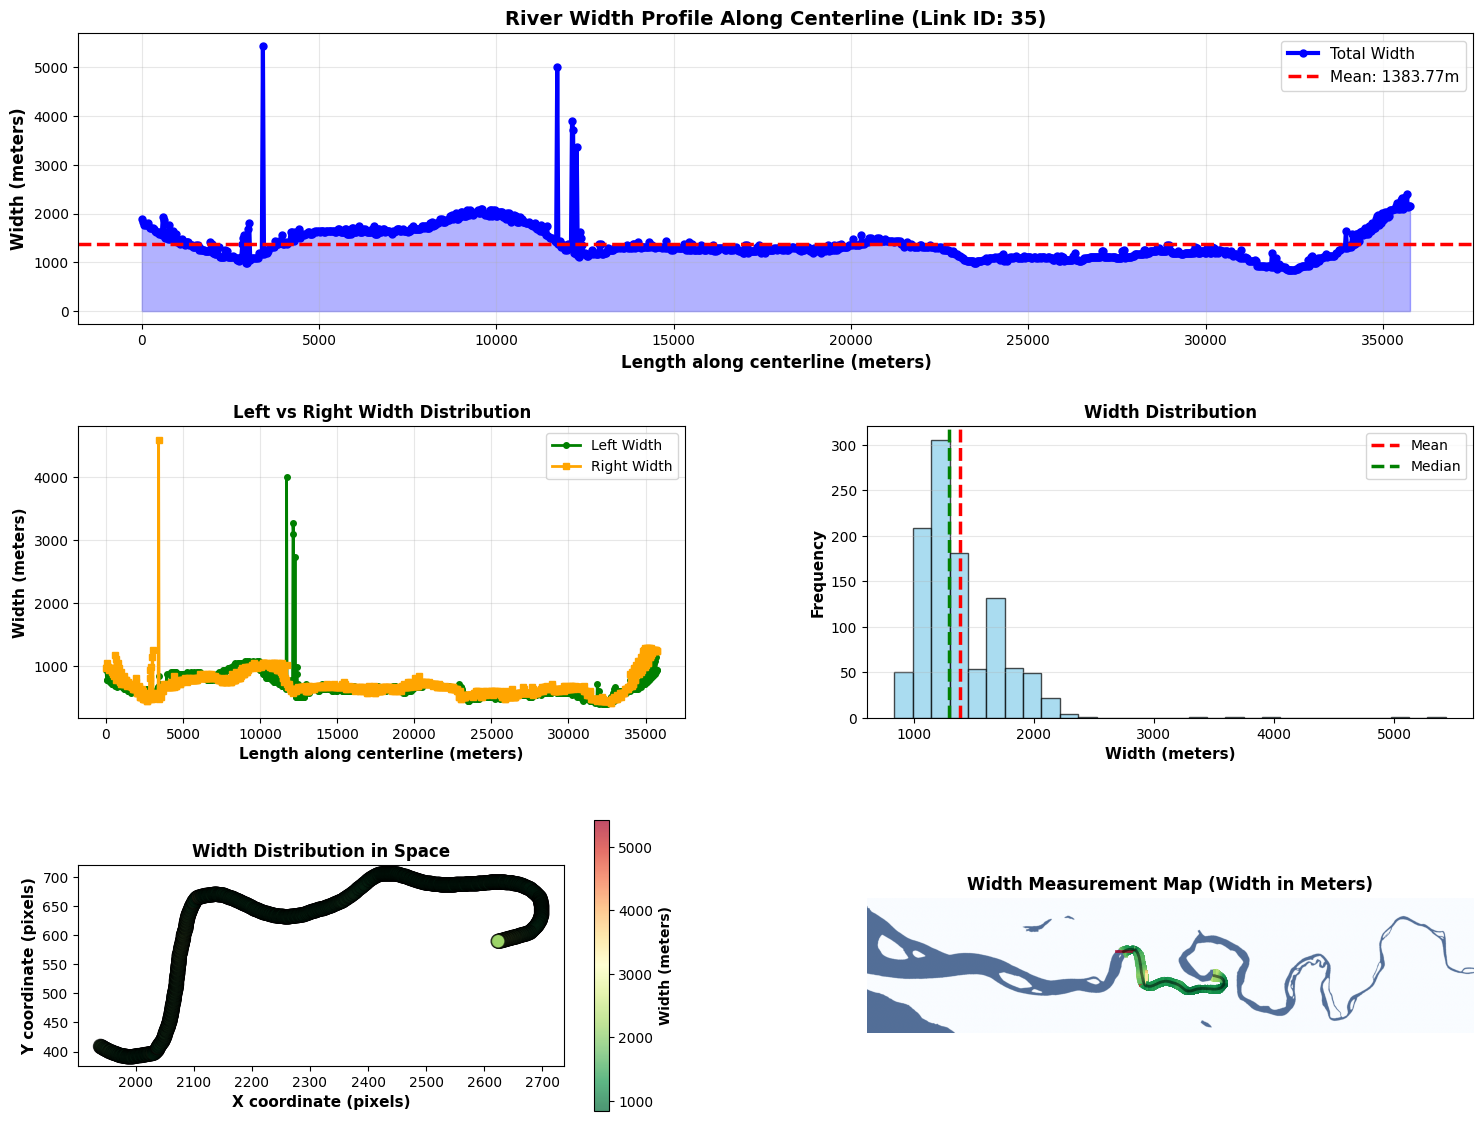

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

# As clarified by the user, 1 pixel is 30m x 30m.
pixel_size_m = 30.0

print(f"\nUsing a pixel size of {pixel_size_m:.2f} meters/pixel for conversion.")

# Create a copy of the DataFrame for conversion to meters
df_selected_link_widths_m = df_selected_link_widths.copy()

# Convert width columns from pixels to meters
df_selected_link_widths_m['width_left_m'] = df_selected_link_widths_m['width_left_pixels'] * pixel_size_m
df_selected_link_widths_m['width_right_m'] = df_selected_link_widths_m['width_right_pixels'] * pixel_size_m
df_selected_link_widths_m['total_width_m'] = df_selected_link_widths_m['total_width_pixels'] * pixel_size_m

# Calculate cumulative length along the centerline in meters
# path_for_selected_link contains (y, x) coordinates in pixel space
cumulative_length_m = [0.0]
for i in range(1, len(path_for_selected_link)):
    p1 = path_for_selected_link[i-1]
    p2 = path_for_selected_link[i]
    # Euclidean distance in pixels
    dist_pixels = np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
    cumulative_length_m.append(cumulative_length_m[-1] + dist_pixels * pixel_size_m)

# Ensure the cumulative_length_m list matches the number of rows in the DataFrame
# The path_for_selected_link corresponds to the points for which widths were measured.
# The 'point_id_within_link' column is essentially an index from 0 to N-1
# So, we should assign the cumulative length to the corresponding points.
# If df_selected_link_widths_m has fewer points than path_for_selected_link,
# we need to ensure correct mapping.
# The 'point_id_within_link' directly corresponds to the indices in path_for_selected_link
if len(cumulative_length_m) == len(df_selected_link_widths_m):
    df_selected_link_widths_m['length_m'] = cumulative_length_m
else:
    # This case should ideally not happen if path_for_selected_link and df_selected_link_widths
    # are generated from the same source points.
    print("Warning: Length of cumulative_length_m does not match df_selected_link_widths_m. Attempting to match by point_id.")
    # Map cumulative_length_m based on point_id_within_link if sizes differ.
    # This assumes point_id_within_link corresponds to indices in path_for_selected_link
    df_selected_link_widths_m['length_m'] = df_selected_link_widths_m['point_id_within_link'].apply(lambda x: cumulative_length_m[x] if x < len(cumulative_length_m) else np.nan)
    df_selected_link_widths_m.dropna(subset=['length_m'], inplace=True)


print("\nConverted DataFrame head (first 5 rows with new meter units):\n")
print(df_selected_link_widths_m[['point_id_within_link', 'length_m', 'total_width_m']].head().to_string())

# Redefine the plotting function to use meter units and update labels
def plot_detailed_width_profile_meters(df_widths, binary_map, x_centerline, y_centerline, link_id, pixel_size_m):
    """Plot detailed width analysis for a single link, with units in meters."""

    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

    # Plot 1: Width profile with left/right breakdown
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df_widths['length_m'], df_widths['total_width_m'],
            'b-', linewidth=3, marker='o', markersize=5, label='Total Width')
    ax1.fill_between(df_widths['length_m'], df_widths['total_width_m'],
                    alpha=0.3, color='blue')
    ax1.axhline(y=df_widths['total_width_m'].mean(), color='r',
               linestyle='--', linewidth=2.5,
               label=f"Mean: {df_widths['total_width_m'].mean():.2f}m")
    ax1.set_xlabel('Length along centerline (meters)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Width (meters)', fontsize=12, fontweight='bold')
    ax1.set_title(f'River Width Profile Along Centerline (Link ID: {link_id})', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11, loc='upper right')

    # Plot 2: Left vs Right width
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(df_widths['length_m'], df_widths['width_left_m'],
            'g-', linewidth=2, marker='o', markersize=4, label='Left Width')
    ax2.plot(df_widths['length_m'], df_widths['width_right_m'],
            'orange', linewidth=2, marker='s', markersize=4, label='Right Width')
    ax2.set_xlabel('Length along centerline (meters)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Width (meters)', fontsize=11, fontweight='bold')
    ax2.set_title('Left vs Right Width Distribution', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=10)

    # Plot 3: Width distribution histogram
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.hist(df_widths['total_width_m'], bins=30, edgecolor='black',
            color='skyblue', alpha=0.7)
    ax3.axvline(x=df_widths['total_width_m'].mean(), color='r',
               linestyle='--', linewidth=2.5, label='Mean')
    ax3.axvline(x=df_widths['total_width_m'].median(), color='g',
               linestyle='--', linewidth=2.5, label='Median')
    ax3.set_xlabel('Width (meters)', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax3.set_title('Width Distribution', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')

    # Plot 4: Spatial width distribution
    ax4 = fig.add_subplot(gs[2, 0])
    # Convert centerline_x and centerline_y to meters for plotting if they are not already.
    # Assuming centerline_x, centerline_y are still in pixels for spatial context,
    # but the color represents width in meters. If the map itself needs to be scaled,
    # that's a larger modification. For now, keep spatial coordinates in pixels for direct
    # overlay on binary_map (which is pixel-based), but color by meter width.
    scatter = ax4.scatter(df_widths['centerline_x'], df_widths['centerline_y'],
                         c=df_widths['total_width_m'], cmap='RdYlGn_r',
                         s=100, alpha=0.7, edgecolors='black', linewidth=1)
    ax4.set_xlabel('X coordinate (pixels)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Y coordinate (pixels)', fontsize=11, fontweight='bold')
    ax4.set_title('Width Distribution in Space', fontsize=12, fontweight='bold')
    ax4.set_aspect('equal')
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Width (meters)', fontsize=10, fontweight='bold')

    # Plot 5: Map with width lines
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.imshow(binary_map, cmap='Blues', alpha=0.7)

    plot_df = df_widths.copy() # Use the modified df with meter widths for color mapping

    # Re-calculate perp_dx, perp_dy if not present in df_widths (df_widths_m)
    if 'perp_dx' not in plot_df.columns or 'perp_dy' not in plot_df.columns:
        temp_perp_dx = []
        temp_perp_dy = []
        for i in range(len(plot_df)):
            if i == 0:
                dx = plot_df['centerline_x'].iloc[i+1] - plot_df['centerline_x'].iloc[i]
                dy = plot_df['centerline_y'].iloc[i+1] - plot_df['centerline_y'].iloc[i]
            elif i == len(plot_df) - 1:
                dx = plot_df['centerline_x'].iloc[i] - plot_df['centerline_x'].iloc[i-1]
                dy = plot_df['centerline_y'].iloc[i] - plot_df['centerline_y'].iloc[i-1]
            else:
                dx = plot_df['centerline_x'].iloc[i+1] - plot_df['centerline_x'].iloc[i-1]
                dy = plot_df['centerline_y'].iloc[i+1] - plot_df['centerline_y'].iloc[i-1]

            tangent_length = np.sqrt(dx**2 + dy**2)
            if tangent_length > 0:
                dx /= tangent_length
                dy /= tangent_length
            else:
                dx, dy = 0, 0 # Fallback for isolated points or zero-length segments

            temp_perp_dx.append(-dy)
            temp_perp_dy.append(dx)
        plot_df['perp_dx'] = temp_perp_dx
        plot_df['perp_dy'] = temp_perp_dy

    colors = plt.cm.RdYlGn_r(
        (plot_df['total_width_m'] - plot_df['total_width_m'].min()) /
        (plot_df['total_width_m'].max() - plot_df['total_width_m'].min())
    )

    # The perp_dx, perp_dy are unit vectors, and width_left_pixels, width_right_pixels
    # are pixel distances which are directly used for plotting on the pixel grid.
    # So we use the original pixel widths for drawing the lines, but the color is based on meters.
    for idx, row in plot_df.iterrows():
        ax5.plot([row['centerline_x'] - row['perp_dx'] * row['width_left_pixels'], # still pixels for plotting
                 row['centerline_x'] + row['perp_dx'] * row['width_right_pixels']], # still pixels for plotting
                [row['centerline_y'] - row['perp_dy'] * row['width_left_pixels'],
                 row['centerline_y'] + row['perp_dy'] * row['width_right_pixels']],
                color=colors[plot_df.index.get_loc(idx)], linewidth=2, alpha=0.8)

    # x_centerline, y_centerline are in pixels
    ax5.plot(x_centerline, y_centerline, 'k-', linewidth=2, alpha=0.5)
    ax5.set_title('Width Measurement Map (Width in Meters)', fontsize=12, fontweight='bold')
    ax5.axis('off')

    plt.tight_layout()
    plt.show()

print("\n" + "="*70)
print("STEP 5: WIDTH PROFILE ANALYSIS FOR A SINGLE SELECTED LINK (IN METERS)")
print("="*70)

# Plot detailed profile for the selected link with meter units
print(f"Plotting detailed width profile for Link ID: {selected_link_id} (in meters)...")
# Pass the original x_centerline_selected, y_centerline_selected (pixel coords) for spatial plots.
# The pixel_size_m is passed to the plotting function for reference, though it's already used to calculate df_widths.
plot_detailed_width_profile_meters(
    df_selected_link_widths_m,
    binary_map,
    x_centerline_selected,
    y_centerline_selected,
    selected_link_id,
    pixel_size_m
)

In [11]:
print(f"Tabulation of detailed width measurements for Link ID {selected_link_id} (in meters):")
display(df_selected_link_widths_m)

Tabulation of detailed width measurements for Link ID 35 (in meters):


,point_id_within_link,centerline_x,centerline_y,width_left_pixels,width_right_pixels,total_width_pixels,original_link_id,width_left_m,width_right_m,total_width_m,length_m
0,0,1939,409,31,32,63,35,930.0,960.0,1890.0,0.000000
1,1,1940,408,26,35,61,35,780.0,1050.0,1830.0,42.426407
2,2,1941,408,26,33,59,35,780.0,990.0,1770.0,72.426407
3,3,1942,407,26,33,59,35,780.0,990.0,1770.0,114.852814
4,4,1943,407,26,33,59,35,780.0,990.0,1770.0,144.852814
...,...,...,...,...,...,...,...,...,...,...,...
1061,1061,2628,591,36,42,78,35,1080.0,1260.0,2340.0,35632.480503
1062,1062,2627,590,38,42,80,35,1140.0,1260.0,2400.0,35674.906909
1063,1063,2626,590,30,41,71,35,900.0,1230.0,2130.0,35704.906909
1064,1064,2625,590,31,41,72,35,930.0,1230.0,2160.0,35734.906909



STEP: VISUALIZING ALL LINKS WITH THEIR IDs (WHITE BACKGROUND)


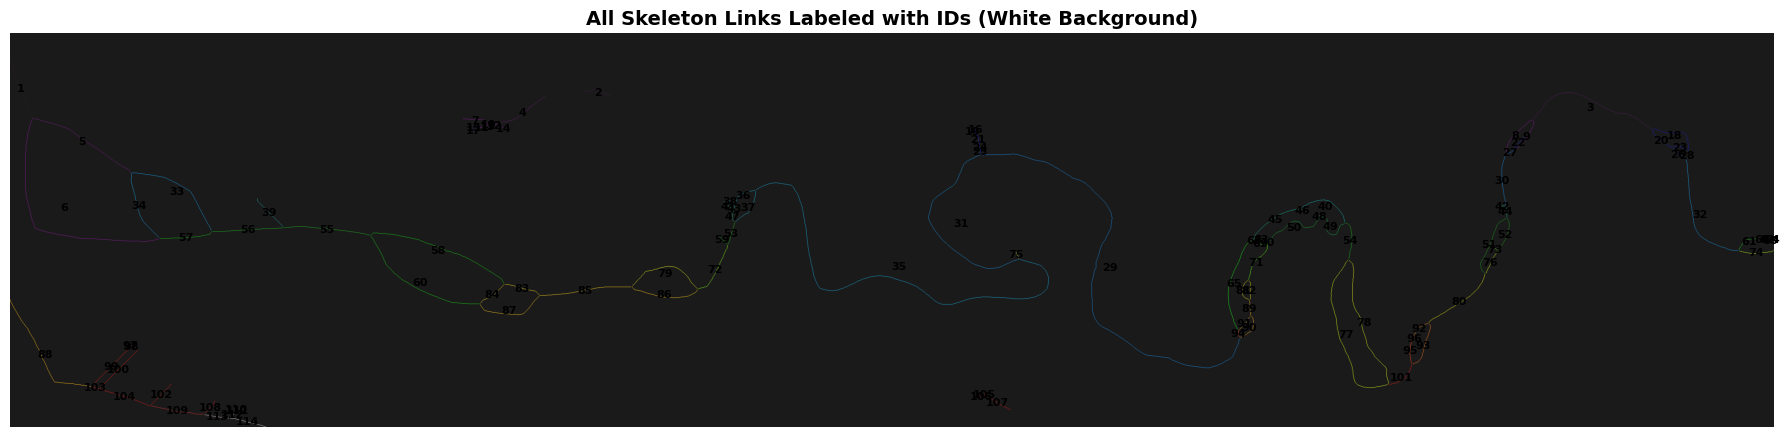

In [12]:
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*70)
print("STEP: VISUALIZING ALL LINKS WITH THEIR IDs (WHITE BACKGROUND)")
print("="*70)

def visualize_all_links_with_ids_white_bg(labeled_links, num_links):
    """
    Visualizes all individual links from the labeled_links array with their IDs
    on a white background.

    Args:
        labeled_links (np.ndarray): An integer array where each connected
          link segment is assigned a unique positive integer label.
        num_links (int): The total number of identified links.
    """
    fig, ax = plt.subplots(figsize=(18, 9))

    # Set the background color of the axes to white
    ax.set_facecolor('white')

    # Use a colormap for distinct labels. Add 1 to num_links for background (label 0).
    # The background is naturally white without plotting binary_map.
    cmap = plt.get_cmap('nipy_spectral', num_links + 1)
    ax.imshow(labeled_links, cmap=cmap, alpha=0.9)

    # Add text labels for each link ID
    for i in range(1, num_links + 1):
        # Get coordinates of the link's pixels
        link_pixels = np.argwhere(labeled_links == i)
        if len(link_pixels) > 0:
            # Calculate the center of the link for placing the label
            center_y, center_x = np.mean(link_pixels, axis=0).astype(int)

            # Adjust label position slightly if needed for better visibility
            ax.text(center_x, center_y, str(i), color='black', fontsize=8, ha='center', va='center', weight='bold')

    ax.set_title('All Skeleton Links Labeled with IDs (White Background)', fontweight='bold', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# Call the function to visualize all links with their IDs on a white background
visualize_all_links_with_ids_white_bg(labeled_links, num_links)



STEP 4: DELETING LINKS WITH ENDPOINTS
Identified 38 links connected to an endpoint for deletion.
✓ 76 links remaining after pruning endpoints.

STEP 5: VISUALIZING PRUNED LINKS


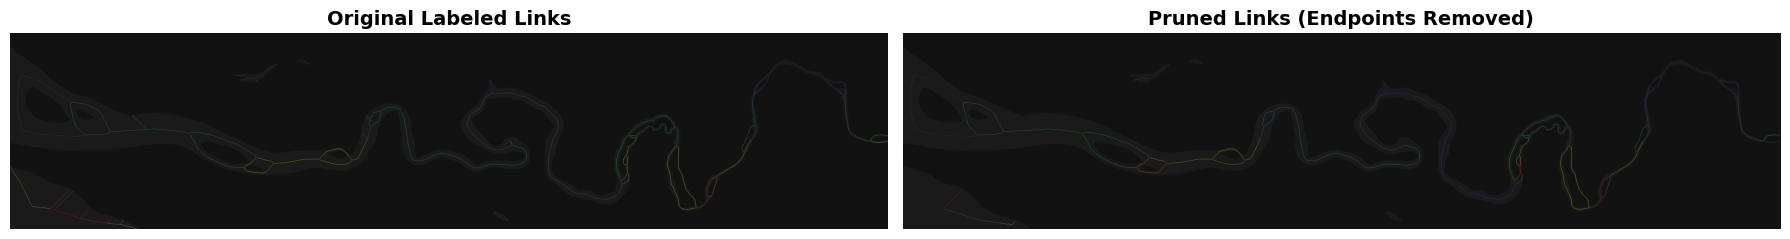

In [13]:
print("\n" + "="*70)
print("STEP 4: DELETING LINKS WITH ENDPOINTS")
print("="*70)

# Create a boolean mask for endpoints for efficient checking
endpoint_mask = np.zeros_like(skeleton, dtype=bool)
for y, x in end_points:
    endpoint_mask[y, x] = True

# Make a copy of labeled_links to modify
pruned_labeled_links = np.copy(labeled_links)

links_to_delete = []
for link_id in range(1, num_links + 1):
    # Get pixels belonging to the current link
    link_pixels_coords = np.argwhere(pruned_labeled_links == link_id)

    # Check if any pixel of this link is an endpoint
    is_endpoint_link = False
    for y, x in link_pixels_coords:
        if endpoint_mask[y, x]:
            is_endpoint_link = True
            break

    if is_endpoint_link:
        links_to_delete.append(link_id)
        # Set pixels of this link to background (0)
        pruned_labeled_links[pruned_labeled_links == link_id] = 0

print(f"Identified {len(links_to_delete)} links connected to an endpoint for deletion.")

# Re-label the remaining links to ensure consecutive numbering
# and update the count of links
pruned_labeled_links, new_num_links = ndimage.label(pruned_labeled_links > 0, structure=np.ones((3,3)))

print(f"✓ {new_num_links} links remaining after pruning endpoints.")


print("\n" + "="*70)
print("STEP 5: VISUALIZING PRUNED LINKS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Plot original labeled links
cmap_orig = plt.get_cmap('nipy_spectral', num_links + 1)
axes[0].imshow(binary_map, cmap='Greys_r', alpha=0.3) # Changed to Greys_r for bright mode
axes[0].imshow(labeled_links, cmap=cmap_orig, alpha=0.9)
axes[0].set_title('Original Labeled Links', fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot pruned labeled links
cmap_pruned = plt.get_cmap('nipy_spectral', new_num_links + 1)
axes[1].imshow(binary_map, cmap='Greys_r', alpha=0.3) # Changed to Greys_r for bright mode
axes[1].imshow(pruned_labeled_links, cmap=cmap_pruned, alpha=0.9)
axes[1].set_title('Pruned Links (Endpoints Removed)', fontweight='bold', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Update global variables for subsequent steps if needed
# labeled_links = pruned_labeled_links
# num_links = new_num_links